# **PART 2: COMPUTER VISION PROBLEM FORMULATION & CNN PROTOTYPE**

In [23]:
# Extracting image dataset
import zipfile
with zipfile.ZipFile('images-20260513T165654Z-3-001.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

# Task 1: Problem Identification

**IMAGE CLASSIFICATION**

The dataset represents an Image Classification problem because each image belongs to one specific category:
- Normal
- Scratch
- Dent
- Stain

 The objective is to classify product surface images into their correct defect category using a Convolutional Neural Network (CNN).

# Task 2: Dataset Exploration

In [24]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [25]:
ds_path = 'dataset/images'

In [26]:
classes = [folder for folder in os.listdir(ds_path)
    if os.path.isdir(os.path.join(ds_path, folder))]
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['dent', 'scratch', 'normal', 'stain']
Number of classes: 4


In [27]:
image_count = {}
for class_name in classes:
    class_path = os.path.join(ds_path, class_name)
    image_count[class_name] = len(os.listdir(class_path))
image_count

{'dent': 120, 'scratch': 120, 'normal': 120, 'stain': 120}

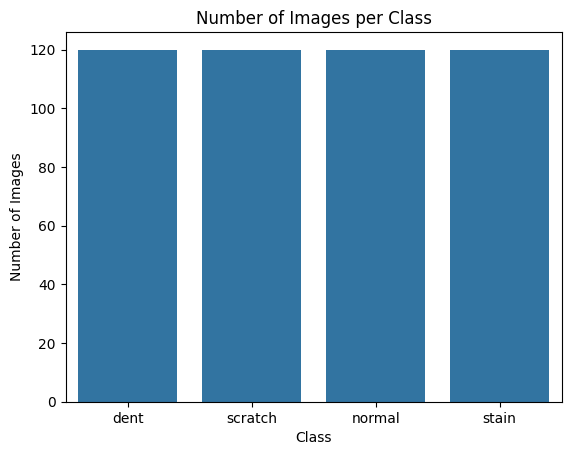

In [28]:
sns.barplot(x=list(image_count.keys()),
    y=list(image_count.values()))
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

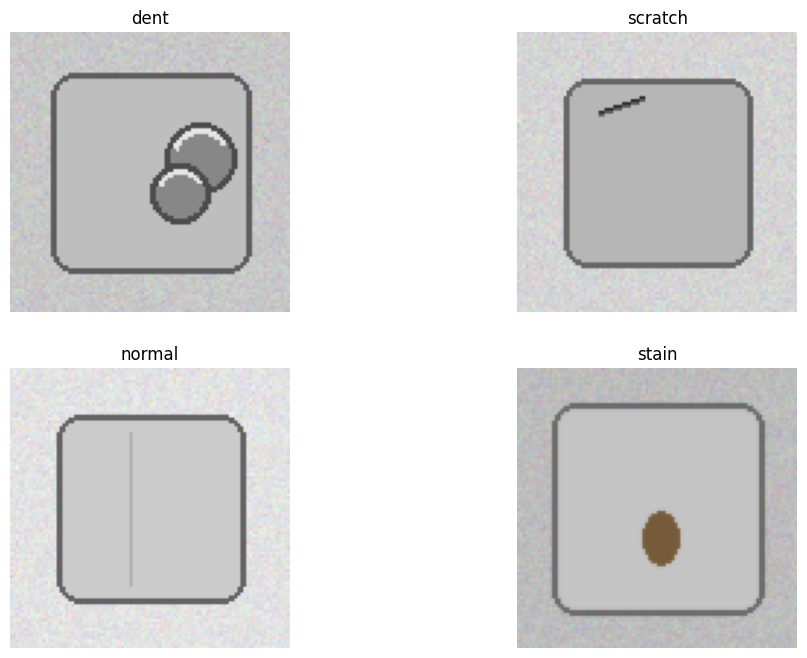

In [29]:
plt.figure(figsize=(12,8))
for i, class_name in enumerate(classes):
    class_path = os.path.join(ds_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 2, i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis('off')
plt.show()

In [30]:
sample_image = image.shape
print("Image dimensions:", sample_image)

Image dimensions: (96, 96, 3)


NOTE:

The dataset contains four image classes representing different manufacturing surface conditions.

Sample images were visualized to understand visual patterns, and class distribution was checked to identify any imbalance in the dataset.

# Task 3: Image Preprocessing

In [31]:
image_size = 128
X = []
y = []
for class_name in classes:
    class_path = os.path.join(ds_path, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Resize image
        image = cv2.resize(image, (image_size, image_size))
# Normalize pixel values
        image = image / 255.0
        X.append(image)
        y.append(class_name)
print("Images loaded successfully")

Images loaded successfully


In [32]:
X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (480, 128, 128, 3)
y shape: (480,)


In [33]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print("Encoded classes:", encoder.classes_)

Encoded classes: ['dent' 'normal' 'scratch' 'stain']


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 384
Testing samples: 96


In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True)
datagen.fit(X_train)
print("Data augmentation applied")

Data augmentation applied


NOTE:

Images were resized to a fixed size of 128x128 pixels for consistent model input.

Pixel values were normalized between 0 and 1 to improve training performance.

Labels were encoded into numerical format, and the dataset was split into training and testing sets.

Data augmentation was applied to improve model generalization.

# Task 4: CNN Model Creation

In [36]:
# Creating CNN model
model = Sequential()

# First convolution layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))

# Pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution layer
model.add(Conv2D(64,(3,3),activation='relu'))

# Second pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model.add(Flatten())

# Dense layer
model.add(Dense(128, activation='relu'))

# Dropout layer
model.add(Dropout(0.5))

# Output layer
model.add(Dense(len(classes), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
# Compiling model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [38]:
# Model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

NOTE:

The CNN model uses convolution layers to extract visual patterns from images.

Pooling layers reduce image dimensions and computational complexity.

The flatten layer converts feature maps into a one-dimensional vector, and dense layers perform classification into the four defect categories.

# Task 5: Model Training & Evaluation

In [39]:
# Training CNN model
hist = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=10)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 851ms/step - accuracy: 0.2917 - loss: 2.0118 - val_accuracy: 0.2500 - val_loss: 1.3860
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 891ms/step - accuracy: 0.3229 - loss: 1.3788 - val_accuracy: 0.2812 - val_loss: 1.3545
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 887ms/step - accuracy: 0.4036 - loss: 1.3274 - val_accuracy: 0.2708 - val_loss: 1.2676
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 895ms/step - accuracy: 0.4818 - loss: 1.2146 - val_accuracy: 0.6250 - val_loss: 1.1102
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 764ms/step - accuracy: 0.5729 - loss: 1.0620 - val_accuracy: 0.7500 - val_loss: 0.9117
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 836ms/step - accuracy: 0.6146 - loss: 0.9712 - val_accuracy: 0.7708 - val_loss: 0.7591
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 893ms/step - accuracy: 0.6354 - loss: 0.8359 - val_accuracy: 0.8229 - val_loss: 0.6874
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 890ms/step - accuracy: 0.7500 - loss: 0.7083 - val_accur

In [40]:
# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accuracy: 0.8438 - loss: 0.5008
Test Loss: 0.5008283257484436
Test Accuracy: 0.84375


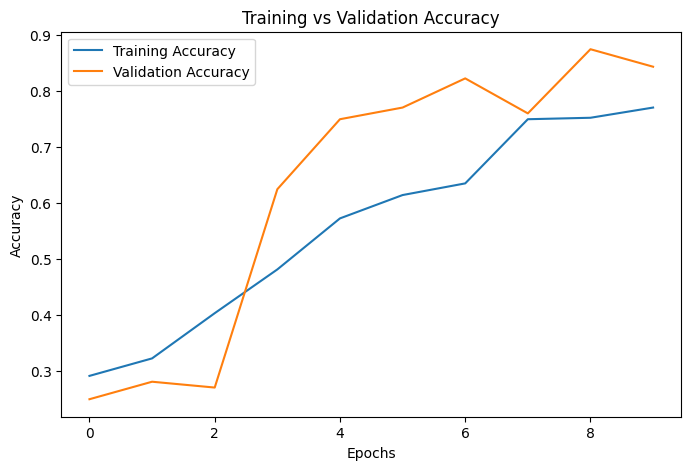

In [41]:
# Plotting accuracy graph
plt.figure(figsize=(8,5))
plt.plot(hist.history['accuracy'], label='Training Accuracy')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

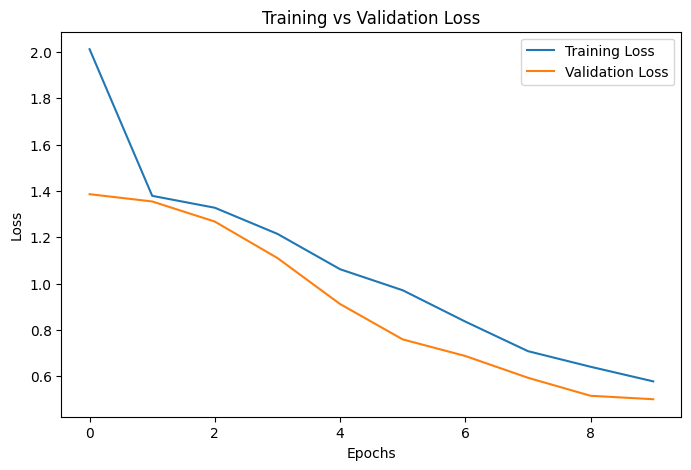

In [42]:
# Plotting loss graph
plt.figure(figsize=(8,5))
plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step


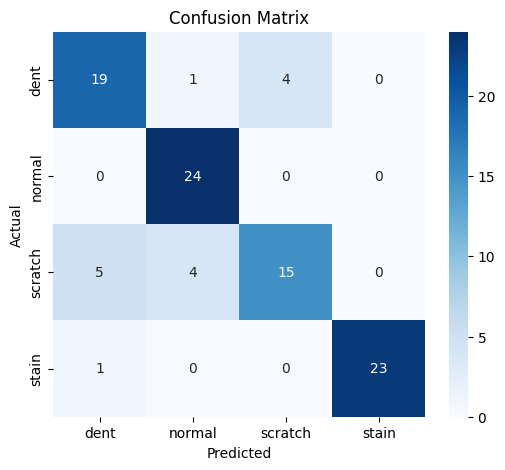

In [43]:
# Predictions for confusion matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
    xticklabels=encoder.classes_,yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

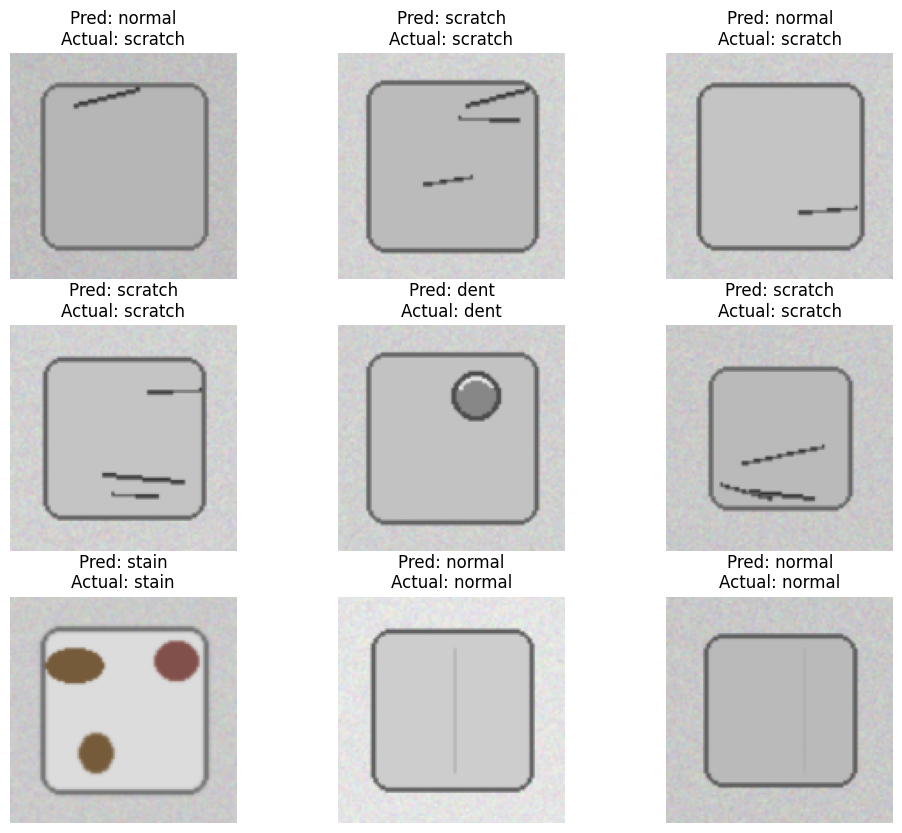

In [44]:
# Display sample predictions
plt.figure(figsize=(12,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    predicted_label = encoder.inverse_transform(
        [y_pred_classes[i]])[0]

    actual_label = encoder.inverse_transform(
        [y_test[i]])[0]
    plt.title(f"Pred: {predicted_label}\nActual: {actual_label}")
    plt.axis('off')
plt.show()

NOTE:

The CNN model achieved strong classification performance on the manufacturing defect dataset.

The training and validation accuracy improved steadily during training, and the confusion matrix showed that most defect categories were classified correctly.

## NOTE: TASK 6 & 7 IN README.md FILE